# Robustness Sweep

This notebook performs robustness sweeps over boundary estimation parameters.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Synthetic Dataset Preparation and Environment Setup

Here we initialize the computational environment (e.g., seeding and device selection) and define the generators for our synthetic 2D datasets (such as XOR, Moons, and Warped Blobs). These controlled environments allow us to precisely probe the spatial structure of teacher-surrogate disagreement without the confounds of high-dimensional data.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy import stats

from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [4]:
# -----------------------------------------------------------------------------
# Dataset generators
# -----------------------------------------------------------------------------

def make_xor(n_samples=1500, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_checkerboard(n_samples=1500, noise=0.03, random_state=42, cells=4):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-2, 2, size=(n_samples, 2))
    cell_x = np.floor((X[:, 0] + 2) / 4 * cells).astype(int)
    cell_y = np.floor((X[:, 1] + 2) / 4 * cells).astype(int)
    y = ((cell_x + cell_y) % 2).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_warped_blobs(n_samples=1500, noise=0.08, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.2, -0.2), (1.2, 0.2)],
        cluster_std=[0.65, 0.65],
        random_state=random_state,
    )
    X = X.copy()
    X[:, 1] = X[:, 1] + 0.85 * np.sin(1.4 * X[:, 0])
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_linear_blobs(n_samples=1500, noise=0.05, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.4, 0), (1.4, 0)],
        cluster_std=[0.55, 0.55],
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_gaussian_overlap(n_samples=1500, random_state=42):
    rng = np.random.default_rng(random_state)
    n0 = n_samples // 2
    n1 = n_samples - n0

    mean0 = np.array([-0.65, 0.0])
    mean1 = np.array([0.65, 0.0])
    cov0 = np.array([[1.0, 0.55], [0.55, 0.85]])
    cov1 = np.array([[1.0, -0.45], [-0.45, 0.85]])

    X0 = rng.multivariate_normal(mean0, cov0, size=n0)
    X1 = rng.multivariate_normal(mean1, cov1, size=n1)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])

    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


def load_dataset(name, n_samples=1500, random_state=42):
    if name == "moons":
        return make_moons(n_samples=n_samples, noise=0.25, random_state=random_state)
    if name == "circles":
        return make_circles(n_samples=n_samples, noise=0.25, factor=0.45, random_state=random_state)
    if name == "xor":
        return make_xor(n_samples=n_samples, random_state=random_state)
    if name == "checkerboard":
        return make_checkerboard(n_samples=n_samples, random_state=random_state)
    if name == "warped_blobs":
        return make_warped_blobs(n_samples=n_samples, random_state=random_state)
    if name == "linear_blobs":
        return make_linear_blobs(n_samples=n_samples, random_state=random_state)
    if name == "gaussian_overlap":
        return make_gaussian_overlap(n_samples=n_samples, random_state=random_state)
    raise ValueError(f"Unknown dataset: {name}")


### Teacher MLP and Surrogate Model Initialization

In this section, we define the architecture for our Multi-Layer Perceptron (MLP) teacher model in PyTorch and establish the fitting routines for our surrogate approximations. This sets up the core components whose decision boundaries we will systematically compare.


In [5]:
# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        return torch.sigmoid(logits).cpu().numpy()


In [6]:
# -----------------------------------------------------------------------------
# Surrogate models
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
    elif name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    elif name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
    elif name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
    elif name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
    else:
        raise ValueError(f"Unknown surrogate: {name}")

    model.fit(X_train, teacher_train_y)
    return model


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


### Geometry-Weighted Fidelity and Boundary Approximation Sweeps

This section forms the core of our robustness checks. We define our novel geometry-weighted fidelity metrics and the grid-based boundary approximation routines. We then systematically sweep over key hyperparameters—such as grid resolution, epsilon-band width, boundary fallback density, and temperature (beta)—to ensure that the observed divergence between confidence-based and geometry-weighted fidelity is robust to boundary estimation choices.


In [7]:
# -----------------------------------------------------------------------------
# Fidelity and weighting functions
# -----------------------------------------------------------------------------

def hard_agreement(teacher_p, surrogate_p):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    return (teacher_y == surrogate_y).astype(float)


def teacher_margin(teacher_p):
    return np.abs(teacher_p - 0.5)


def normalized_weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)

    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan

    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def confidence_weights(teacher_p, alpha=10.0):
    return np.exp(-alpha * teacher_margin(teacher_p))


def geometry_weights(boundary_distances, beta=2.0):
    return np.exp(-beta * boundary_distances)


In [8]:
# -----------------------------------------------------------------------------
# Boundary approximation
# -----------------------------------------------------------------------------

def make_grid(X, margin=0.75, grid_size=350):
    x_min = X[:, 0].min() - margin
    x_max = X[:, 0].max() + margin
    y_min = X[:, 1].min() - margin
    y_max = X[:, 1].max() + margin

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def approximate_boundary_points(
    teacher,
    X_reference,
    grid_size=350,
    margin=0.75,
    band_eps=0.015,
    fallback_k=2500,
):
    xx, yy, grid = make_grid(X_reference, margin=margin, grid_size=grid_size)
    grid_p = teacher_probs(teacher, grid)
    margins = np.abs(grid_p - 0.5)

    boundary_points = grid[margins <= band_eps]
    used_fallback = False

    if len(boundary_points) < 50:
        used_fallback = True
        k = min(fallback_k, len(grid))
        closest_idx = np.argpartition(margins, k - 1)[:k]
        boundary_points = grid[closest_idx]

    return {
        "grid": grid,
        "grid_p": grid_p,
        "grid_margins": margins,
        "boundary_points": boundary_points,
        "used_fallback": used_fallback,
        "n_boundary_points": len(boundary_points),
    }


def nearest_boundary_distances(X_eval, boundary_points):
    tree = cKDTree(boundary_points)
    distances, _ = tree.query(X_eval, k=1)
    return distances


In [9]:
# -----------------------------------------------------------------------------
# Caching teacher/surrogate predictions before robustness sweeps
# -----------------------------------------------------------------------------

def prepare_case(dataset_name, seed, surrogate_name, n_samples=1500):
    X, y = load_dataset(dataset_name, n_samples=n_samples, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.35,
        random_state=seed,
        stratify=y,
    )

    teacher = train_teacher(X_train, y_train, seed=seed)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)

    teacher_test_p = teacher_probs(teacher, X_test)
    surrogate_test_p = surrogate_probs(surrogate, X_test)
    agreement = hard_agreement(teacher_test_p, surrogate_test_p)
    conf_w = confidence_weights(teacher_test_p, alpha=10.0)

    return {
        "dataset": dataset_name,
        "seed": seed,
        "surrogate": surrogate_name,
        "X": X,
        "X_test": X_test,
        "teacher": teacher,
        "teacher_test_p": teacher_test_p,
        "surrogate_test_p": surrogate_test_p,
        "agreement": agreement,
        "confidence_weighted_fidelity": normalized_weighted_average(agreement, conf_w),
        "global_fidelity": float(np.mean(agreement)),
    }


In [10]:
# -----------------------------------------------------------------------------
# Robustness sweep evaluation
# -----------------------------------------------------------------------------

def evaluate_geometry_setting(case, grid_size, band_eps, fallback_k, beta=2.0):
    boundary_info = approximate_boundary_points(
        case["teacher"],
        X_reference=case["X"],
        grid_size=grid_size,
        band_eps=band_eps,
        fallback_k=fallback_k,
    )

    distances = nearest_boundary_distances(case["X_test"], boundary_info["boundary_points"])
    geo_w = geometry_weights(distances, beta=beta)
    geo_fid = normalized_weighted_average(case["agreement"], geo_w)

    margin_distance_corr = stats.spearmanr(
        teacher_margin(case["teacher_test_p"]),
        distances,
    ).correlation

    return {
        "dataset": case["dataset"],
        "seed": case["seed"],
        "surrogate": case["surrogate"],
        "grid_size": grid_size,
        "band_eps": band_eps,
        "fallback_k": fallback_k,
        "beta": beta,
        "global_fidelity": case["global_fidelity"],
        "confidence_weighted_fidelity": case["confidence_weighted_fidelity"],
        "geometry_weighted_fidelity": geo_fid,
        "global_minus_geometry": case["global_fidelity"] - geo_fid,
        "confidence_minus_geometry": case["confidence_weighted_fidelity"] - geo_fid,
        "margin_distance_spearman": margin_distance_corr,
        "n_boundary_points": boundary_info["n_boundary_points"],
        "used_fallback": boundary_info["used_fallback"],
        "mean_boundary_distance": float(np.mean(distances)),
        "median_boundary_distance": float(np.median(distances)),
    }


In [11]:
# -----------------------------------------------------------------------------
# Sweep configuration
# -----------------------------------------------------------------------------
# This is intentionally moderate. Increase seeds/datasets later if needed.

DATASETS = [
    "moons",
    "warped_blobs",
    "gaussian_overlap",
    "linear_blobs",
    "xor",
    "circles",
]

SURROGATES = [
    "logistic_regression",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

SEEDS = list(range(3))

GRID_SIZES = [150, 250, 350, 500]
BAND_EPS_VALUES = [0.005, 0.010, 0.015, 0.030, 0.050]
FALLBACK_K_VALUES = [500, 1500, 2500, 5000]
BETA_VALUES = [1.0, 2.0, 4.0]

# Use this canonical setting for one-at-a-time sweeps.
BASE_GRID_SIZE = 350
BASE_BAND_EPS = 0.015
BASE_FALLBACK_K = 2500
BASE_BETA = 2.0


In [12]:
# -----------------------------------------------------------------------------
# Prepare cases
# -----------------------------------------------------------------------------

cases = []

for dataset_name in DATASETS:
    print(f"\n=== Preparing dataset: {dataset_name} ===")
    for seed in SEEDS:
        print(f"  seed {seed}")
        for surrogate_name in SURROGATES:
            cases.append(prepare_case(dataset_name, seed, surrogate_name))

print(f"Prepared {len(cases)} teacher/surrogate cases.")



=== Preparing dataset: moons ===
  seed 0
  seed 1
  seed 2

=== Preparing dataset: warped_blobs ===
  seed 0
  seed 1
  seed 2

=== Preparing dataset: gaussian_overlap ===
  seed 0
  seed 1
  seed 2

=== Preparing dataset: linear_blobs ===
  seed 0
  seed 1
  seed 2

=== Preparing dataset: xor ===
  seed 0
  seed 1
  seed 2

=== Preparing dataset: circles ===
  seed 0
  seed 1
  seed 2
Prepared 54 teacher/surrogate cases.


In [13]:
# -----------------------------------------------------------------------------
# Run one-at-a-time robustness sweeps
# -----------------------------------------------------------------------------

rows = []

for i, case in enumerate(cases):
    print(f"Case {i + 1}/{len(cases)}: {case['dataset']} / seed {case['seed']} / {case['surrogate']}")

    # Sweep grid size.
    for grid_size in GRID_SIZES:
        rows.append({
            "sweep_type": "grid_size",
            "sweep_value": grid_size,
            **evaluate_geometry_setting(
                case,
                grid_size=grid_size,
                band_eps=BASE_BAND_EPS,
                fallback_k=BASE_FALLBACK_K,
                beta=BASE_BETA,
            ),
        })

    # Sweep epsilon boundary band.
    for band_eps in BAND_EPS_VALUES:
        rows.append({
            "sweep_type": "band_eps",
            "sweep_value": band_eps,
            **evaluate_geometry_setting(
                case,
                grid_size=BASE_GRID_SIZE,
                band_eps=band_eps,
                fallback_k=BASE_FALLBACK_K,
                beta=BASE_BETA,
            ),
        })

    # Sweep fallback density.
    for fallback_k in FALLBACK_K_VALUES:
        rows.append({
            "sweep_type": "fallback_k",
            "sweep_value": fallback_k,
            **evaluate_geometry_setting(
                case,
                grid_size=BASE_GRID_SIZE,
                band_eps=BASE_BAND_EPS,
                fallback_k=fallback_k,
                beta=BASE_BETA,
            ),
        })

    # Sweep beta.
    for beta in BETA_VALUES:
        rows.append({
            "sweep_type": "beta",
            "sweep_value": beta,
            **evaluate_geometry_setting(
                case,
                grid_size=BASE_GRID_SIZE,
                band_eps=BASE_BAND_EPS,
                fallback_k=BASE_FALLBACK_K,
                beta=beta,
            ),
        })

robustness = pd.DataFrame(rows)
robustness


Case 1/54: moons / seed 0 / logistic_regression
Case 2/54: moons / seed 0 / decision_tree_depth_4
Case 3/54: moons / seed 0 / small_mlp_surrogate
Case 4/54: moons / seed 1 / logistic_regression
Case 5/54: moons / seed 1 / decision_tree_depth_4
Case 6/54: moons / seed 1 / small_mlp_surrogate
Case 7/54: moons / seed 2 / logistic_regression
Case 8/54: moons / seed 2 / decision_tree_depth_4
Case 9/54: moons / seed 2 / small_mlp_surrogate
Case 10/54: warped_blobs / seed 0 / logistic_regression
Case 11/54: warped_blobs / seed 0 / decision_tree_depth_4
Case 12/54: warped_blobs / seed 0 / small_mlp_surrogate
Case 13/54: warped_blobs / seed 1 / logistic_regression
Case 14/54: warped_blobs / seed 1 / decision_tree_depth_4
Case 15/54: warped_blobs / seed 1 / small_mlp_surrogate
Case 16/54: warped_blobs / seed 2 / logistic_regression
Case 17/54: warped_blobs / seed 2 / decision_tree_depth_4
Case 18/54: warped_blobs / seed 2 / small_mlp_surrogate
Case 19/54: gaussian_overlap / seed 0 / logistic_reg

,sweep_type,sweep_value,dataset,seed,surrogate,grid_size,band_eps,fallback_k,beta,global_fidelity,confidence_weighted_fidelity,geometry_weighted_fidelity,global_minus_geometry,confidence_minus_geometry,margin_distance_spearman,n_boundary_points,used_fallback,mean_boundary_distance,median_boundary_distance
0,grid_size,150.000,moons,0,logistic_regression,150,0.015,2500,2.0,0.883810,0.724128,0.819483,0.064327,-0.095355,0.911757,2500,True,0.356815,0.306891
1,grid_size,250.000,moons,0,logistic_regression,250,0.015,2500,2.0,0.883810,0.724128,0.794241,0.089568,-0.070114,0.802777,154,False,0.608668,0.578538
2,grid_size,350.000,moons,0,logistic_regression,350,0.015,2500,2.0,0.883810,0.724128,0.792097,0.091712,-0.067970,0.798174,255,False,0.603565,0.569135
3,grid_size,500.000,moons,0,logistic_regression,500,0.015,2500,2.0,0.883810,0.724128,0.791729,0.092081,-0.067601,0.800212,548,False,0.603599,0.572875
4,band_eps,0.005,moons,0,logistic_regression,350,0.005,2500,2.0,0.883810,0.724128,0.790391,0.093418,-0.066264,0.798734,80,False,0.614345,0.587262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,fallback_k,2500.000,circles,2,small_mlp_surrogate,350,0.015,2500,2.0,0.967619,0.748472,0.934674,0.032945,-0.186202,0.966616,434,False,0.468554,0.429586
860,fallback_k,5000.000,circles,2,small_mlp_surrogate,350,0.015,5000,2.0,0.967619,0.748472,0.934674,0.032945,-0.186202,0.966616,434,False,0.468554,0.429586
861,beta,1.000,circles,2,small_mlp_surrogate,350,0.015,2500,1.0,0.967619,0.748472,0.952145,0.015474,-0.203673,0.966616,434,False,0.468554,0.429586
862,beta,2.000,circles,2,small_mlp_surrogate,350,0.015,2500,2.0,0.967619,0.748472,0.934674,0.032945,-0.186202,0.966616,434,False,0.468554,0.429586


### Result Aggregation and Stability Artifact Export

We aggregate the raw sweep data to compute stability summaries across our sweep parameters. The resulting tabular metrics, including dataset-level aggregations and coefficient of variation checks for geometry-weighted fidelity, are saved to CSVs for downstream inclusion in the final paper.


In [14]:
robustness.to_csv("robustness_sweep_raw.csv", index=False)
print("Saved robustness_sweep_raw.csv")


Saved robustness_sweep_raw.csv


In [15]:
# -----------------------------------------------------------------------------
# Summary tables
# -----------------------------------------------------------------------------

summary = (
    robustness
    .groupby(["sweep_type", "sweep_value"])
    .agg(
        geometry_weighted_mean=("geometry_weighted_fidelity", "mean"),
        geometry_weighted_std=("geometry_weighted_fidelity", "std"),
        confidence_minus_geometry_mean=("confidence_minus_geometry", "mean"),
        confidence_minus_geometry_std=("confidence_minus_geometry", "std"),
        global_minus_geometry_mean=("global_minus_geometry", "mean"),
        global_minus_geometry_std=("global_minus_geometry", "std"),
        margin_distance_spearman_mean=("margin_distance_spearman", "mean"),
        n_boundary_points_mean=("n_boundary_points", "mean"),
        fallback_rate=("used_fallback", "mean"),
    )
    .reset_index()
)

summary


,sweep_type,sweep_value,geometry_weighted_mean,geometry_weighted_std,confidence_minus_geometry_mean,confidence_minus_geometry_std,global_minus_geometry_mean,global_minus_geometry_std,margin_distance_spearman_mean,n_boundary_points_mean,fallback_rate
0,band_eps,0.005,0.863692,0.140070,-0.089712,0.076654,0.040682,0.033652,0.824492,558.000000,0.166667
1,band_eps,0.010,0.863232,0.140038,-0.089252,0.076328,0.041142,0.033620,0.824106,567.000000,0.111111
2,band_eps,0.015,0.863234,0.139923,-0.089254,0.076185,0.041140,0.033747,0.825434,708.611111,0.111111
3,band_eps,0.030,0.863389,0.139868,-0.089409,0.076312,0.040984,0.033266,0.821334,872.666667,0.000000
4,band_eps,0.050,0.864069,0.139595,-0.090089,0.076405,0.040305,0.032830,0.823054,1434.722222,0.000000
5,beta,1.000,0.883574,0.135971,-0.109594,0.085442,0.020800,0.018217,0.825434,708.611111,0.111111
6,beta,2.000,0.863234,0.139923,-0.089254,0.076185,0.041140,0.033747,0.825434,708.611111,0.111111
7,beta,4.000,0.826167,0.146904,-0.052187,0.062987,0.078207,0.058673,0.825434,708.611111,0.111111
8,fallback_k,500.000,0.863157,0.139857,-0.089177,0.076277,0.041217,0.033682,0.822743,486.388889,0.111111
9,fallback_k,1500.000,0.863193,0.139888,-0.089212,0.076233,0.041181,0.033716,0.824062,597.500000,0.111111


In [16]:
summary.to_csv("robustness_sweep_summary.csv", index=False)
print("Saved robustness_sweep_summary.csv")


Saved robustness_sweep_summary.csv


In [17]:
# Dataset-level summaries are helpful for detecting whether one dataset drives instability.
dataset_summary = (
    robustness
    .groupby(["dataset", "sweep_type", "sweep_value"])
    .agg(
        geometry_weighted_mean=("geometry_weighted_fidelity", "mean"),
        confidence_minus_geometry_mean=("confidence_minus_geometry", "mean"),
        global_minus_geometry_mean=("global_minus_geometry", "mean"),
        margin_distance_spearman_mean=("margin_distance_spearman", "mean"),
        n_boundary_points_mean=("n_boundary_points", "mean"),
        fallback_rate=("used_fallback", "mean"),
    )
    .reset_index()
)

dataset_summary


,dataset,sweep_type,sweep_value,geometry_weighted_mean,confidence_minus_geometry_mean,global_minus_geometry_mean,margin_distance_spearman_mean,n_boundary_points_mean,fallback_rate
0,circles,band_eps,0.005,0.770381,-0.131478,0.038931,0.934367,146.000000,0.0
1,circles,band_eps,0.010,0.770192,-0.131288,0.039121,0.934597,292.000000,0.0
2,circles,band_eps,0.015,0.770440,-0.131536,0.038872,0.934932,437.666667,0.0
3,circles,band_eps,0.030,0.770384,-0.131481,0.038928,0.936214,867.000000,0.0
4,circles,band_eps,0.050,0.770970,-0.132066,0.038342,0.937511,1448.333333,0.0
...,...,...,...,...,...,...,...,...,...
91,xor,fallback_k,5000.000,0.806573,-0.109365,0.027924,0.976816,443.333333,0.0
92,xor,grid_size,150.000,0.808409,-0.111200,0.026089,0.958241,93.333333,0.0
93,xor,grid_size,250.000,0.806560,-0.109352,0.027937,0.971521,224.333333,0.0
94,xor,grid_size,350.000,0.806573,-0.109365,0.027924,0.976816,443.333333,0.0


In [18]:
dataset_summary.to_csv("robustness_sweep_dataset_summary.csv", index=False)
print("Saved robustness_sweep_dataset_summary.csv")


Saved robustness_sweep_dataset_summary.csv


### Stability Diagnostics and Hyperparameter Sensitivity Visualization

Finally, we generate diagnostic plots to visually inspect how the geometry-weighted fidelity and the gap between confidence and geometry metrics vary as we perturb the boundary approximation hyperparameters. These visualizations confirm the qualitative stability of our findings.


In [19]:
# -----------------------------------------------------------------------------
# Plot helper
# -----------------------------------------------------------------------------

def plot_sweep(summary_df, sweep_type, y_col, ylabel, title, filename):
    subset = summary_df[summary_df["sweep_type"] == sweep_type].sort_values("sweep_value")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(subset["sweep_value"], subset[y_col], marker="o")
    ax.set_xlabel(sweep_type)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if sweep_type in ["band_eps", "beta"]:
        ax.set_xscale("log")

    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()


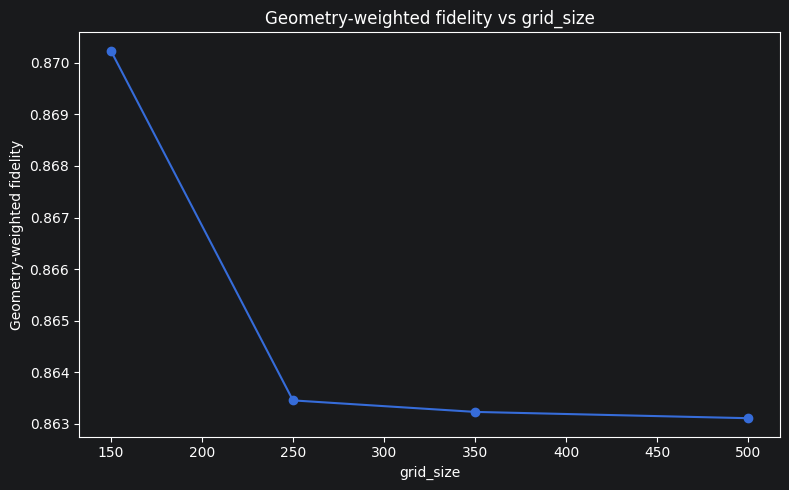

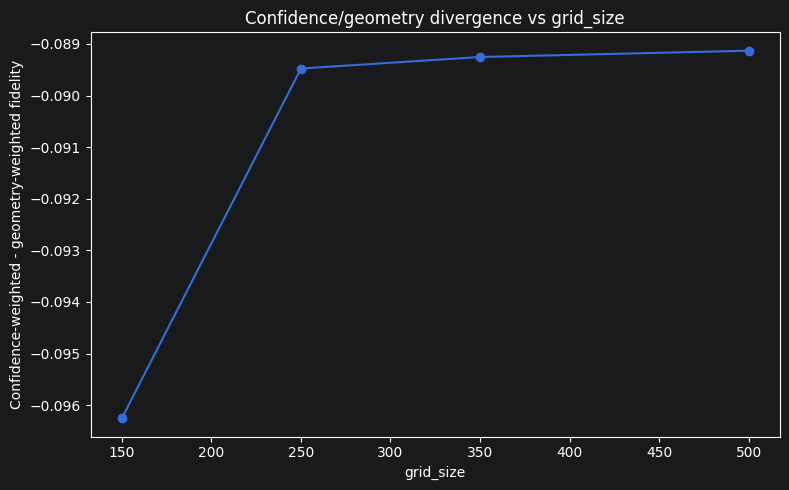

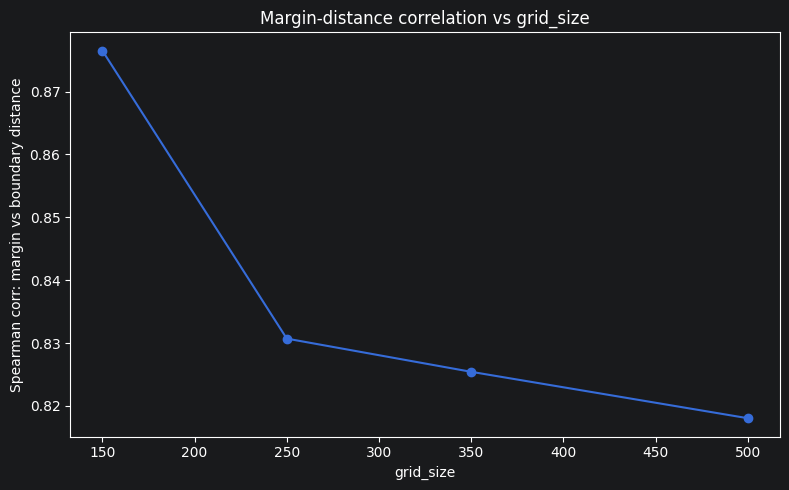

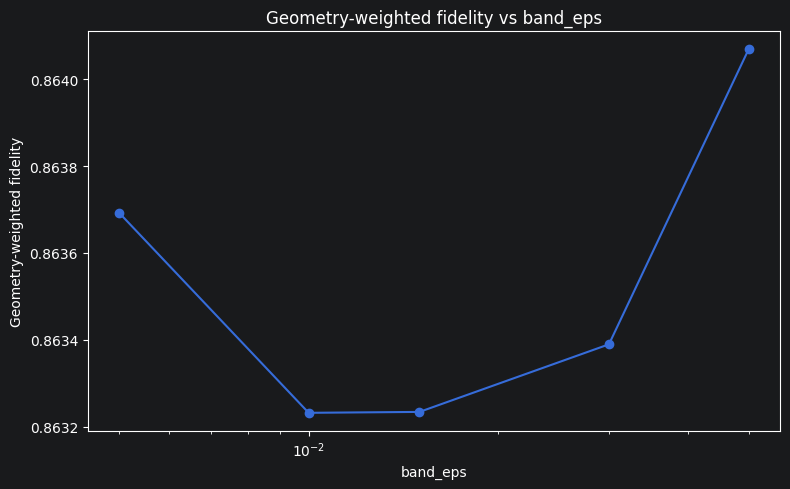

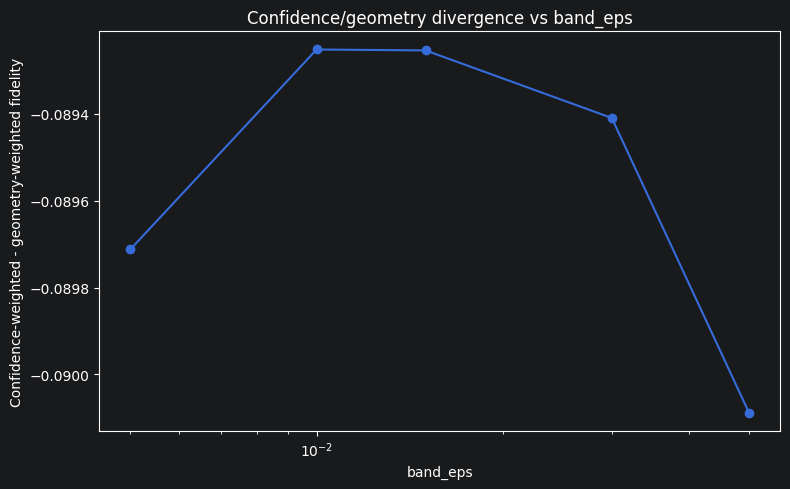

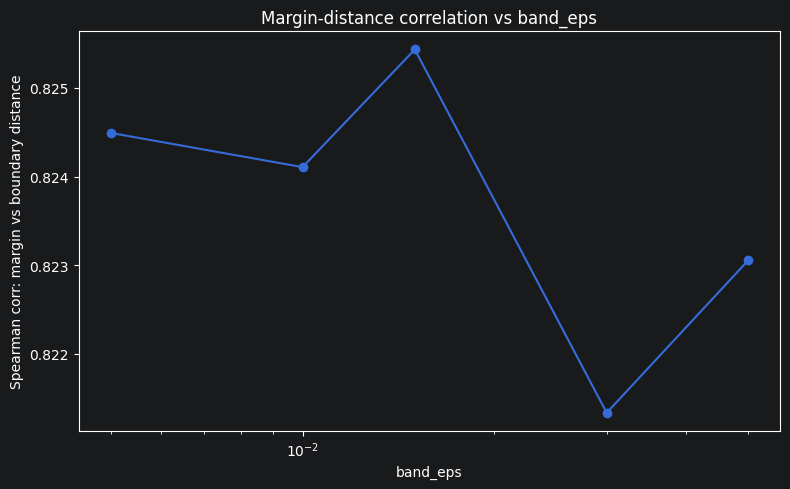

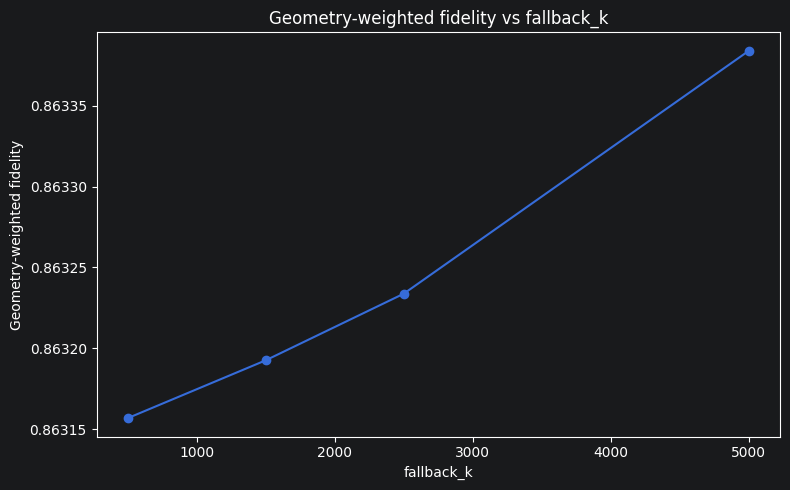

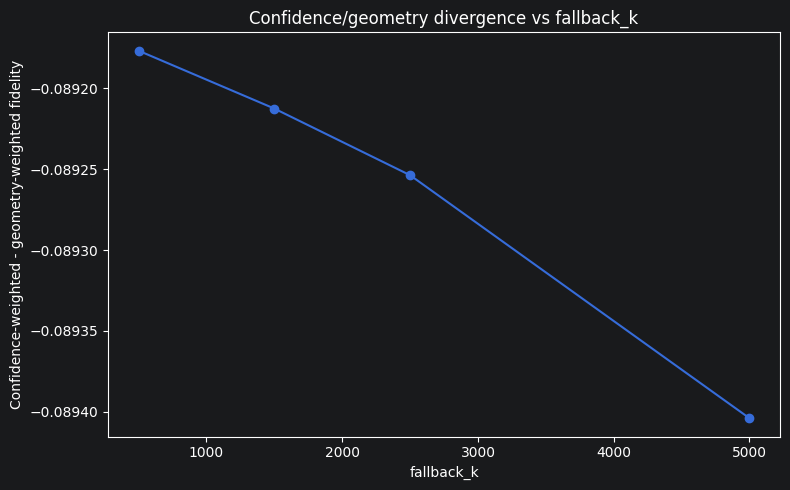

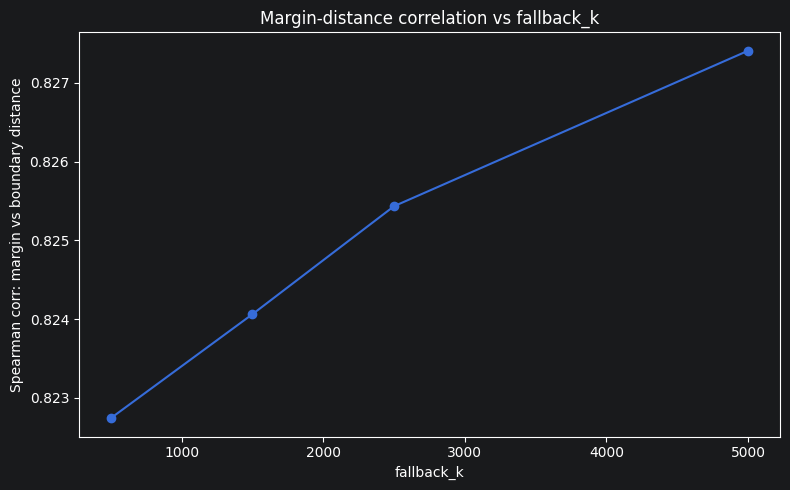

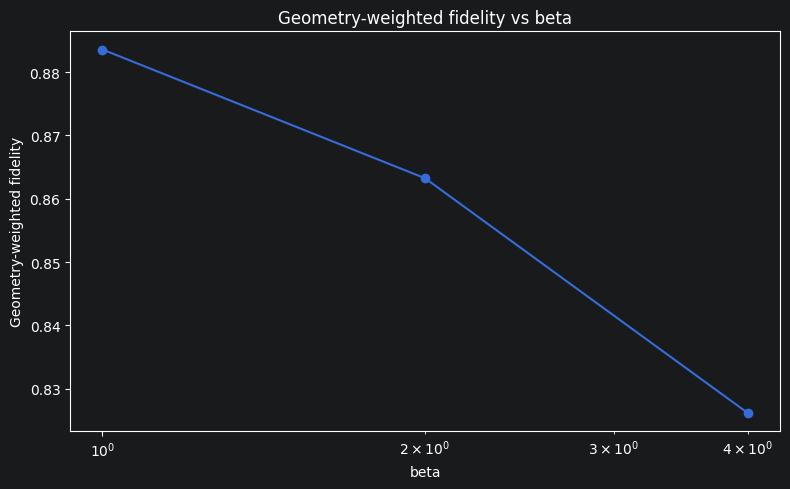

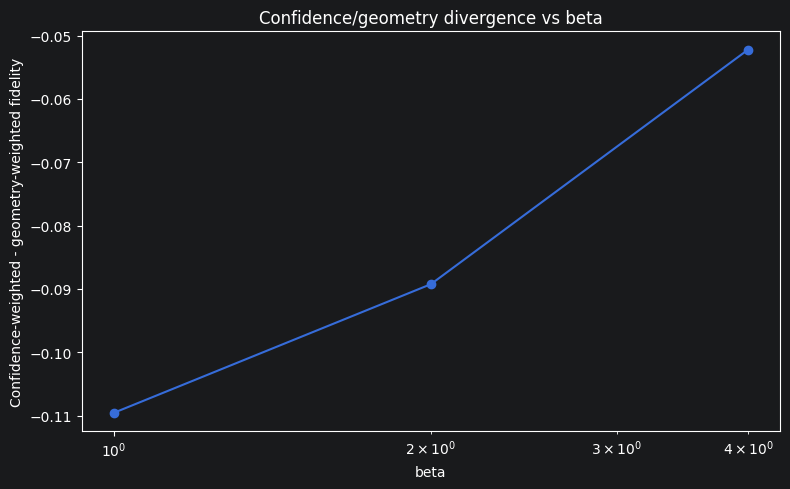

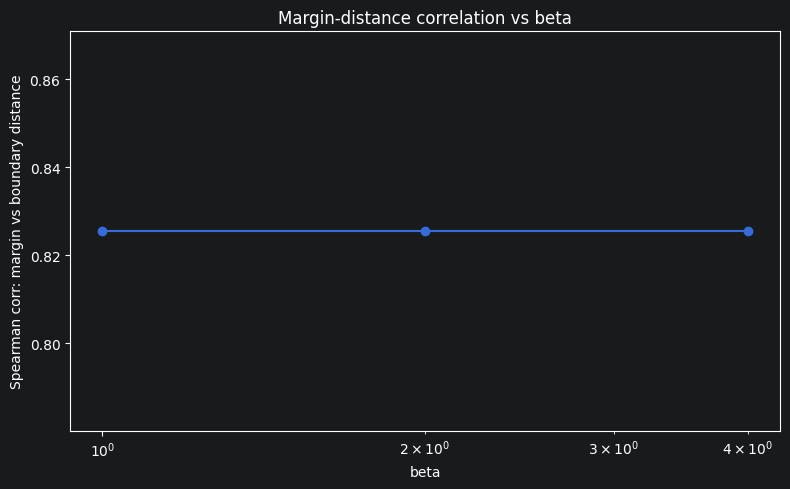

In [20]:
# -----------------------------------------------------------------------------
# Main robustness plots
# -----------------------------------------------------------------------------

for sweep_type in ["grid_size", "band_eps", "fallback_k", "beta"]:
    plot_sweep(
        summary,
        sweep_type,
        "geometry_weighted_mean",
        "Geometry-weighted fidelity",
        f"Geometry-weighted fidelity vs {sweep_type}",
        f"robustness_geometry_weighted_vs_{sweep_type}.png",
    )

    plot_sweep(
        summary,
        sweep_type,
        "confidence_minus_geometry_mean",
        "Confidence-weighted - geometry-weighted fidelity",
        f"Confidence/geometry divergence vs {sweep_type}",
        f"robustness_conf_minus_geo_vs_{sweep_type}.png",
    )

    plot_sweep(
        summary,
        sweep_type,
        "margin_distance_spearman_mean",
        "Spearman corr: margin vs boundary distance",
        f"Margin-distance correlation vs {sweep_type}",
        f"robustness_margin_distance_corr_vs_{sweep_type}.png",
    )


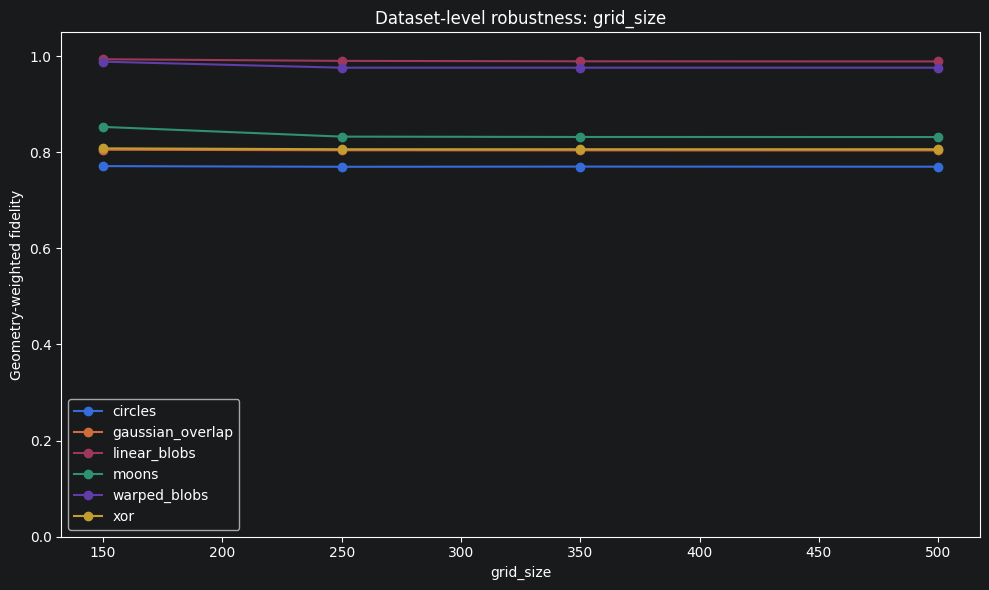

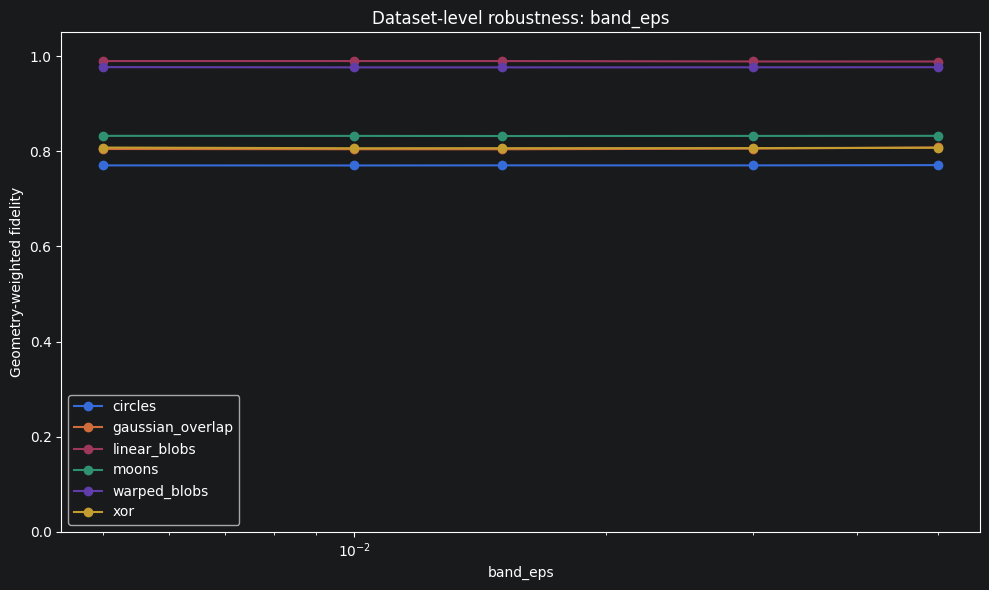

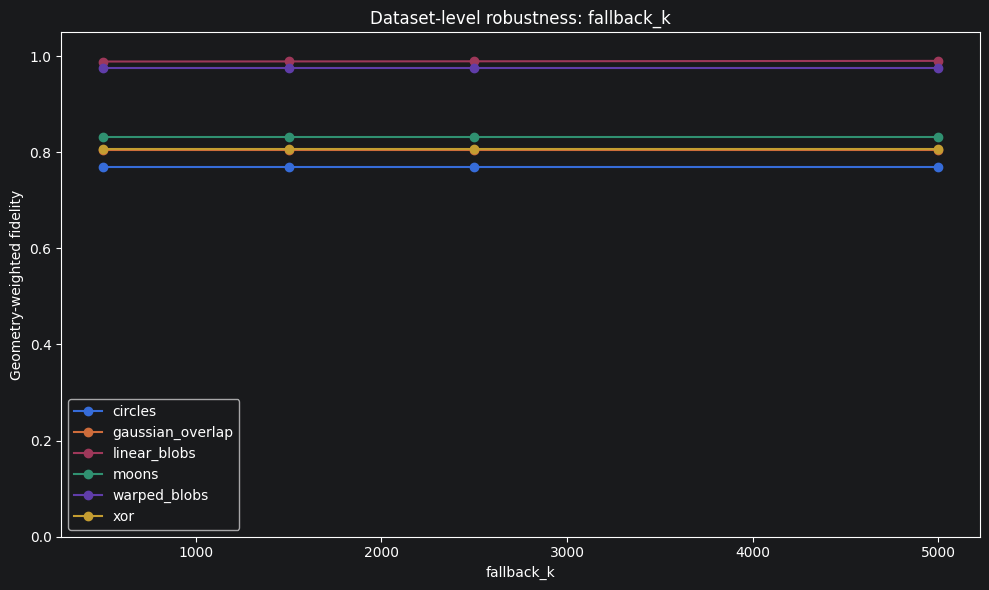

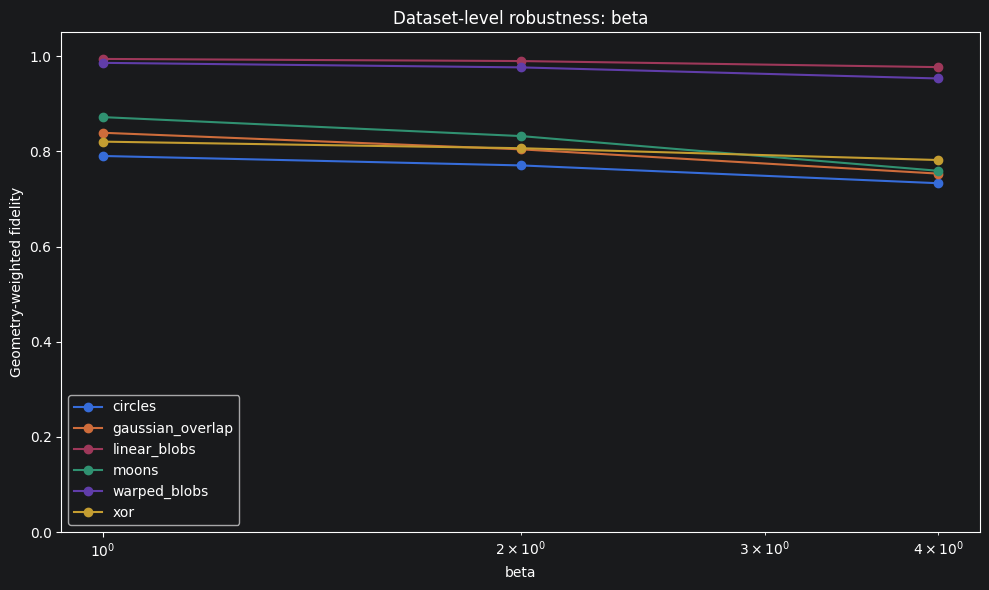

In [21]:
# -----------------------------------------------------------------------------
# Dataset-level plots for geometry-weighted fidelity
# -----------------------------------------------------------------------------

for sweep_type in ["grid_size", "band_eps", "fallback_k", "beta"]:
    subset = dataset_summary[dataset_summary["sweep_type"] == sweep_type].copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    for dataset_name, group in subset.groupby("dataset"):
        group = group.sort_values("sweep_value")
        ax.plot(
            group["sweep_value"],
            group["geometry_weighted_mean"],
            marker="o",
            label=dataset_name,
        )

    if sweep_type in ["band_eps", "beta"]:
        ax.set_xscale("log")

    ax.set_ylim(0, 1.05)
    ax.set_xlabel(sweep_type)
    ax.set_ylabel("Geometry-weighted fidelity")
    ax.set_title(f"Dataset-level robustness: {sweep_type}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"robustness_dataset_geometry_weighted_vs_{sweep_type}.png", dpi=200)
    plt.show()


In [22]:
# -----------------------------------------------------------------------------
# Stability diagnostics
# -----------------------------------------------------------------------------
# Coefficient of variation by sweep type/dataset for geometry-weighted fidelity.

stability = (
    robustness
    .groupby(["dataset", "surrogate", "seed", "sweep_type"])
    .agg(
        mean_geo=("geometry_weighted_fidelity", "mean"),
        std_geo=("geometry_weighted_fidelity", "std"),
        min_geo=("geometry_weighted_fidelity", "min"),
        max_geo=("geometry_weighted_fidelity", "max"),
        mean_conf_minus_geo=("confidence_minus_geometry", "mean"),
        std_conf_minus_geo=("confidence_minus_geometry", "std"),
    )
    .reset_index()
)

stability["geo_range"] = stability["max_geo"] - stability["min_geo"]
stability["geo_cv"] = stability["std_geo"] / stability["mean_geo"]

stability_summary = (
    stability
    .groupby("sweep_type")
    .agg(
        mean_geo_range=("geo_range", "mean"),
        max_geo_range=("geo_range", "max"),
        mean_geo_cv=("geo_cv", "mean"),
        max_geo_cv=("geo_cv", "max"),
        mean_conf_minus_geo_std=("std_conf_minus_geo", "mean"),
    )
    .reset_index()
)

stability_summary


,sweep_type,mean_geo_range,max_geo_range,mean_geo_cv,max_geo_cv,mean_conf_minus_geo_std
0,band_eps,0.002104,0.012631,0.001096,0.007257,0.000891
1,beta,0.057407,0.160374,0.035562,0.104772,0.029148
2,fallback_k,0.000227,0.004081,0.000103,0.001965,0.000101
3,grid_size,0.008105,0.062995,0.004522,0.037988,0.003894


In [23]:
stability.to_csv("robustness_sweep_stability_by_case.csv", index=False)
stability_summary.to_csv("robustness_sweep_stability_summary.csv", index=False)
print("Saved robustness stability summaries")


Saved robustness stability summaries


In [24]:
# -----------------------------------------------------------------------------
# Main textual checks
# -----------------------------------------------------------------------------

print("Robustness questions addressed:")
print("1. Does geometry-weighted fidelity change substantially with grid resolution?")
print("2. Does the confidence-vs-geometry divergence survive changes in epsilon-band width?")
print("3. Does fallback boundary density affect conclusions?")
print("4. Does beta sensitivity change the qualitative story?")
print("5. Are any datasets/surrogates unusually unstable under boundary approximation choices?")

print("\nKey files written:")
print("- robustness_sweep_raw.csv")
print("- robustness_sweep_summary.csv")
print("- robustness_sweep_dataset_summary.csv")
print("- robustness_sweep_stability_by_case.csv")
print("- robustness_sweep_stability_summary.csv")

Robustness questions addressed:
1. Does geometry-weighted fidelity change substantially with grid resolution?
2. Does the confidence-vs-geometry divergence survive changes in epsilon-band width?
3. Does fallback boundary density affect conclusions?
4. Does beta sensitivity change the qualitative story?
5. Are any datasets/surrogates unusually unstable under boundary approximation choices?

Key files written:
- robustness_sweep_raw.csv
- robustness_sweep_summary.csv
- robustness_sweep_dataset_summary.csv
- robustness_sweep_stability_by_case.csv
- robustness_sweep_stability_summary.csv
